In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber


In [5]:
def plot_predictions(test, predicted):
    plt.plot(test, color='red',label='Real IBM Stock Price')
    plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("-" * 30 )
    print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
    print("-" * 30)

def return_mae(test, predicted):
    mae = mean_absolute_error(test, predicted)
    mape = mean_absolute_percentage_error(test, predicted) * 100
    print("Średni błąd bezwzględny: {:.2f}.".format(mae))
    print("Średni błąd bezwzględny procentowy: {:.2f}.".format(mape))
    print("-" * 30 )


In [6]:
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()


,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [7]:
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values


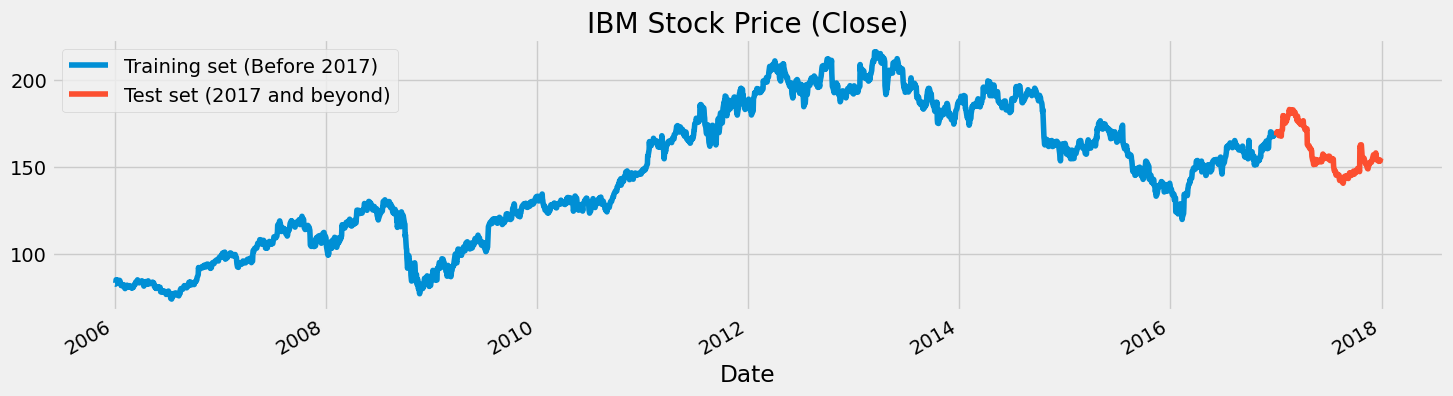

In [8]:

dataset["High"][:'2016'].plot(figsize=(16,4), legend=True)
dataset["High"]['2017':].plot(figsize=(16,4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM Stock Price (Close)')
plt.show()


In [9]:

sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)


In [10]:

X_train = []
y_train = []

for i in range(60, 2769):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)


In [11]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


In [12]:

regressor = Sequential()

regressor.add(Input(shape=(X_train.shape[1], 1)))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop', loss='mean_squared_error')


regressor.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32
)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - loss: 0.0198
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0092
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.0083
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 0.0067
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0063
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0056
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0051
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.0050
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0043
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - loss: 0.0042
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0040
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - loss: 0.0040
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0037
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0031
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0033

In [13]:
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)


In [14]:
X_test = []

for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step


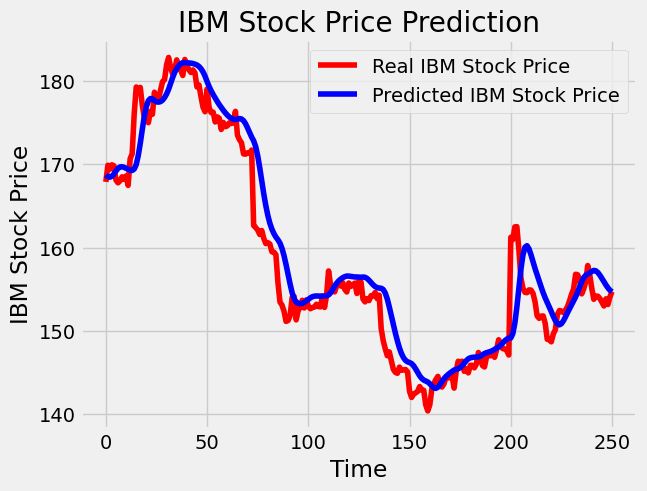

In [15]:
plot_predictions(test_set, predicted_stock_price)


In [16]:
return_rmse(test_set,predicted_stock_price)
return_mae(test_set,predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 3.22.
------------------------------
Średni błąd bezwzględny: 2.31.
Średni błąd bezwzględny procentowy: 1.46.
------------------------------


In [17]:

regressorGRU = Sequential()

regressorGRU.add(Input(shape=(X_train.shape[1], 1)))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(Dense(units=1))

regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

regressorGRU.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 144ms/step - loss: 0.0186
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 0.0085
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - loss: 0.0074
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - loss: 0.0061
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 0.0056
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0051
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0043
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0045
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0039
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0036
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0036
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0035
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0032
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0032
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10

In [18]:
X_test = []

for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


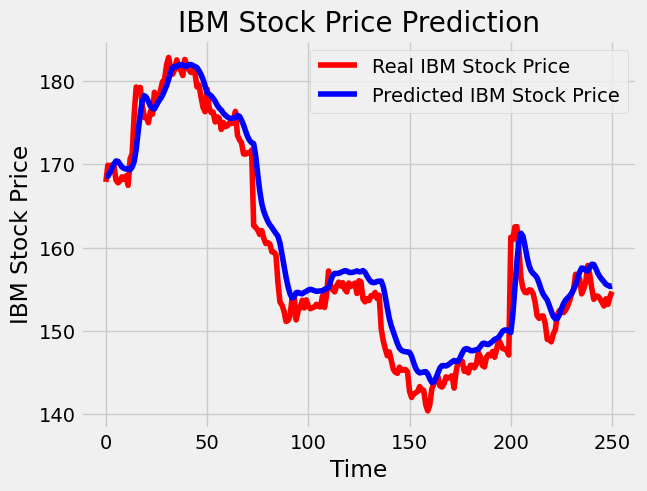

In [19]:
plot_predictions(test_set, GRU_predicted_stock_price)


In [20]:
return_rmse(test_set, GRU_predicted_stock_price)
return_mae(test_set, GRU_predicted_stock_price)


------------------------------
Błąd średniokwadratowy modelu 2.93.
------------------------------
Średni błąd bezwzględny: 2.32.
Średni błąd bezwzględny procentowy: 1.49.
------------------------------


In [21]:
# A): LSTM z 100 units

regressorA = Sequential()

regressorA.add(Input(shape=(X_train.shape[1], 1)))

regressorA.add(LSTM(units=100, return_sequences=True))
regressorA.add(Dropout(0.2))

regressorA.add(LSTM(units=100, return_sequences=True))
regressorA.add(Dropout(0.2))

regressorA.add(LSTM(units=100, return_sequences=True))
regressorA.add(Dropout(0.2))

regressorA.add(LSSTM(units=100))
regressorA.add(Dropout(0.2))

regressorA.add(Dense(units=1))

regressorA.compile(optimizer='rmsprop', loss='mean_squared_error')

historyA = regressorA.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32
)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - loss: 0.0344
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - loss: 0.0124
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 147ms/step - loss: 0.0091
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - loss: 0.0072
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - loss: 0.0060
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - loss: 0.0050
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - loss: 0.0046
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - loss: 0.0042
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 138ms/step - loss: 0.0043
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 138ms/step - loss: 0.0034
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - loss: 0.0033
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - loss: 0.0030
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - loss: 0.0032
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - loss: 0.0027
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 

In [22]:
#predykcja modelu A

X_test_A = []

for i in range(60, len(inputs)):
    X_test_A.append(inputs[i-60:i, 0])

X_test_A = np.array(X_test_A)
X_test_A = np.reshape(X_test_A, (X_test_A.shape[0], X_test_A.shape[1], 1))

A_predicted_stock_price = regressorA.predict(X_test_A)
A_predicted_stock_price = sc.inverse_transform(A_predicted_stock_price)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step


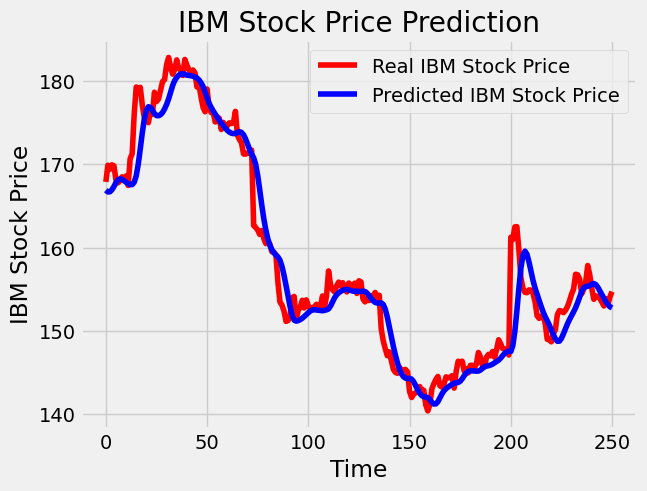

In [23]:
#wykres modelu A
plot_predictions(test_set, A_predicted_stock_price)


In [24]:
# metryki modelu A
return_rmse(test_set, A_predicted_stock_price)
return_mae(test_set, A_predicted_stock_price)


------------------------------
Błąd średniokwadratowy modelu 2.83.
------------------------------
Średni błąd bezwzględny: 1.88.
Średni błąd bezwzględny procentowy: 1.18.
------------------------------


In [25]:
# B) LSTM z optymalizatorem Adam

regressor_adam = Sequential()

regressor_adam.add(Input(shape=(X_train.shape[1], 1)))

regressor_adam.add(LSTM(units=50, return_sequences=True))
regressor_adam.add(Dropout(0.2))

regressor_adam.add(LSTM(units=50, return_sequences=True))
regressor_adam.add(Dropout(0.2))

regressor_adam.add(LSTM(units=50, return_sequences=True))
regressor_adam.add(Dropout(0.2))

regressor_adam.add(LSTM(units=50))
regressor_adam.add(Dropout(0.2))

regressor_adam.add(Dense(units=1))

regressor_adam.compile(optimizer='adam', loss='mean_squared_error')

history_adam = regressor_adam.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32
)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - loss: 0.0289
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0052
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0046
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0042
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0043
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0043
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0037
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0040
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0035
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0033
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 0.0032
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0030
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0030
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0027
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 0.0029
Ep

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step


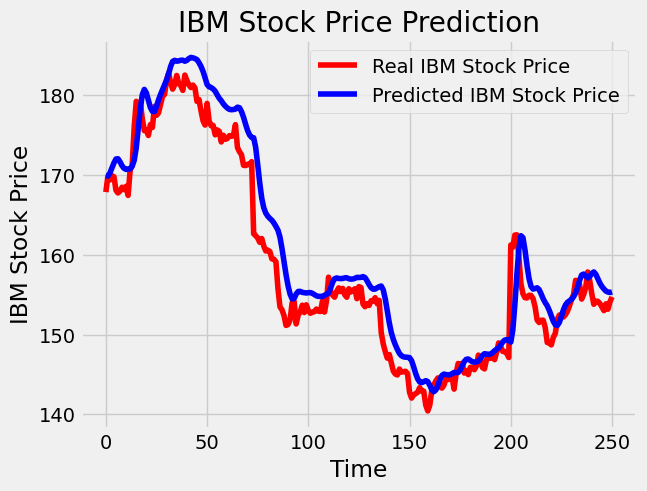

------------------------------
Błąd średniokwadratowy modelu 3.53.
------------------------------
Średni błąd bezwzględny: 2.78.
Średni błąd bezwzględny procentowy: 1.74.
------------------------------


In [26]:
# predykcja i metryki dla Adam

X_test_adam = []

for i in range(60, len(inputs)):
    X_test_adam.append(inputs[i-60:i, 0])

X_test_adam = np.array(X_test_adam)
X_test_adam = np.reshape(X_test_adam, (X_test_adam.shape[0], X_test_adam.shape[1], 1))

adam_predicted_stock_price = regressor_adam.predict(X_test_adam)
adam_predicted_stock_price = sc.inverse_transform(adam_predicted_stock_price)

plot_predictions(test_set, adam_predicted_stock_price)

return_rmse(test_set, adam_predicted_stock_price)
return_mae(test_set, adam_predicted_stock_price)


In [27]:
# C) LSTM z funkcją straty MAE

regressor_mae = Sequential()

regressor_mae.add(Input(shape=(X_train.shape[1], 1)))

regressor_mae.add(LSTM(units=50, return_sequences=True))
regressor_mae.add(Dropout(0.2))

regressor_mae.add(LSTM(units=50, return_sequences=True))
regressor_mae.add(Dropout(0.2))

regressor_mae.add(LSTM(units=50, return_sequences=True))
regressor_mae.add(Dropout(0.2))

regressor_mae.add(LSTM(units=50))
regressor_mae.add(Dropout(0.2))

regressor_mae.add(Dense(units=1))

regressor_mae.compile(optimizer='rmsprop', loss='mae')

history_mae = regressor_mae.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32
)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - loss: 0.1145
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0788
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 0.0668
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - loss: 0.0626
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - loss: 0.0571
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.0549
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0528
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0509
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0487
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - loss: 0.0478
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 0.0462
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - loss: 0.0440
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0447
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0434
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


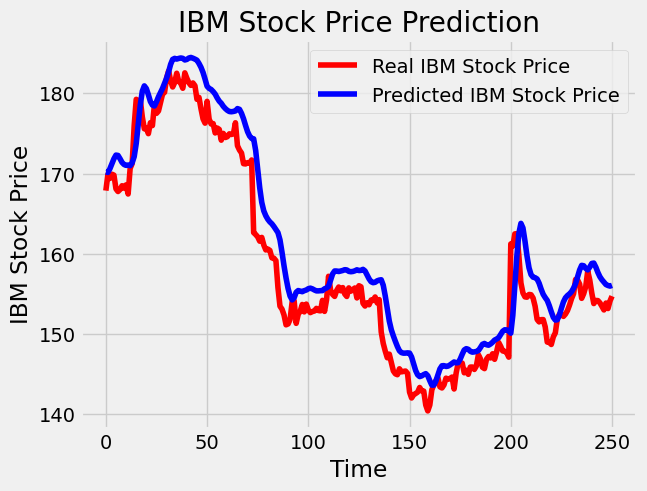

------------------------------
Błąd średniokwadratowy modelu 3.62.
------------------------------
Średni błąd bezwzględny: 3.08.
Średni błąd bezwzględny procentowy: 1.94.
------------------------------


In [28]:
# predykcja i metryki dla MAE

X_test_mae = []

for i in range(60, len(inputs)):
    X_test_mae.append(inputs[i-60:i, 0])

X_test_mae = np.array(X_test_mae)
X_test_mae = np.reshape(X_test_mae, (X_test_mae.shape[0], X_test_mae.shape[1], 1))

mae_predicted_stock_price = regressor_mae.predict(X_test_mae)
mae_predicted_stock_price = sc.inverse_transform(mae_predicted_stock_price)

plot_predictions(test_set, mae_predicted_stock_price)

return_rmse(test_set, mae_predicted_stock_price)
return_mae(test_set, mae_predicted_stock_price)


In [29]:
# D) Przygotowanie danych dla atrybutu Close

dataset_close = dataset[['Close']]

training_set_close = dataset_close[:'2016'].values
test_set_close = dataset_close['2017':].values

sc_close = MinMaxScaler(feature_range=(0, 1))
training_set_scaled_close = sc_close.fit_transform(training_set_close)

X_train_close = []
y_train_close = []

for i in range(120, len(training_set_scaled_close)):
    X_train_close.append(training_set_scaled_close[i-120:i, 0])
    y_train_close.append(training_set_scaled_close[i, 0])

X_train_close = np.array(X_train_close)
y_train_close = np.array(y_train_close)

X_train_close = np.reshape(X_train_close, (X_train_close.shape[0], X_train_close.shape[1], 1))


In [30]:
# E) LSTM dla Close i EarlyStopping na val_loss

regressor_close = Sequential()

regressor_close.add(Input(shape=(X_train_close.shape[1], 1)))

regressor_close.add(LSTM(units=100, return_sequences=True))
regressor_close.add(Dropout(0.2))

regressor_close.add(LSTM(units=100, return_sequences=True))
regressor_close.add(Dropout(0.2))

regressor_close.add(LSTM(units=100))
regressor_close.add(Dropout(0.2))

regressor_close.add(Dense(units=1))

regressor_close.compile(optimizer='adam', loss='mean_squared_error')

early_stop_close = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_close = regressor_close.fit(
    X_train_close, y_train_close,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_close]
)


Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 172ms/step - loss: 0.0156 - val_loss: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 180ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 185ms/step - loss: 0.0029 - val_loss: 0.0022
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - loss: 0.0026 - val_loss: 8.4084e-04
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 174ms/step - loss: 0.0027 - val_loss: 8.5044e-04
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 186ms/step - loss: 0.0024 - val_loss: 9.5652e-04
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - loss: 0.0028 - val_loss: 9.1906e-04
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 166ms/step - loss: 0.0022 - val_loss: 6.8388e-04
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 175ms/step - loss: 0.0022 - val_loss: 6.4732e-04
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 188ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 172ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


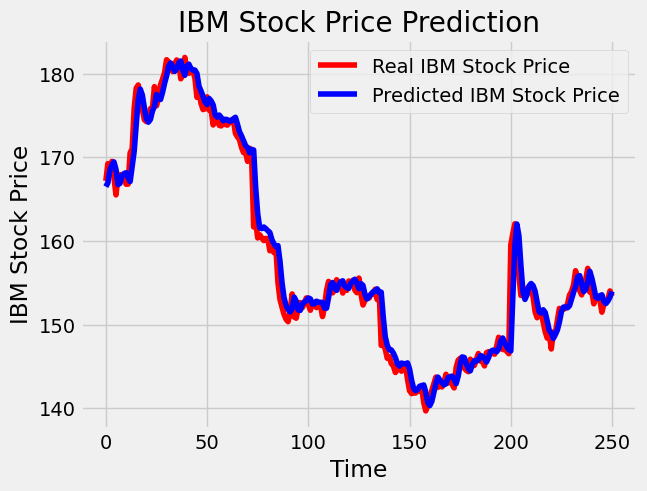

------------------------------
Błąd średniokwadratowy modelu 1.85.
------------------------------
Średni błąd bezwzględny: 1.23.
Średni błąd bezwzględny procentowy: 0.78.
------------------------------


In [32]:
# Predykcja i metryki dla Close

dataset_total_close = pd.concat((dataset_close[:'2016'], dataset_close['2017':]), axis=0)
inputs_close = dataset_total_close[len(dataset_total_close) - len(test_set_close) - 60:].values
inputs_close = inputs_close.reshape(-1, 1)
inputs_close = sc_close.transform(inputs_close)

X_test_close = []

for i in range(60, len(inputs_close)):
    X_test_close.append(inputs_close[i-60:i, 0])

X_test_close = np.array(X_test_close)
X_test_close = np.reshape(X_test_close, (X_test_close.shape[0], X_test_close.shape[1], 1))

close_predicted_price = regressor_close.predict(X_test_close)
close_predicted_price = sc_close.inverse_transform(close_predicted_price)

plot_predictions(test_set_close, close_predicted_price)

return_rmse(test_set_close, close_predicted_price)
return_mae(test_set_close, close_predicted_price)
